# **Face Book Food Trend Analysis**

**Import libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load dataset**

In [5]:
df=pd.read_excel('/content/foodtrends_facebook_cleaned.xlsx')

**Basic Information**

In [6]:

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape of dataset: (1000, 16)

Columns:
 Index(['post_id', 'post_type', 'food_category', 'brand_name', 'post_date',
       'post_time', 'likes_count', 'comments_count', 'shares_count', 'love',
       'wow', 'sad', 'angry', 'day_of_week', 'time_of_day',
       'total_engagement'],
      dtype='object')

Data Types:
 post_id                      int64
post_type                   object
food_category               object
brand_name                  object
post_date           datetime64[ns]
post_time                    int64
likes_count                  int64
comments_count               int64
shares_count                 int64
love                         int64
wow                          int64
sad                          int64
angry                        int64
day_of_week                 object
time_of_day                 object
total_engagement             int64
dtype: object


**Missing Values**

In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 post_id             0
post_type           0
food_category       0
brand_name          0
post_date           0
post_time           0
likes_count         0
comments_count      0
shares_count        0
love                0
wow                 0
sad                 0
angry               0
day_of_week         0
time_of_day         0
total_engagement    0
dtype: int64


**Statistical Summary**

In [8]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
            post_id                   post_date    post_time  likes_count  \
count  1000.000000                        1000  1000.000000  1000.000000   
mean    500.500000  2025-01-21 08:03:50.400000    11.436000    99.807000   
min       1.000000         2025-01-01 00:00:00     0.000000    67.000000   
25%     250.750000         2025-01-11 00:00:00     5.000000    93.000000   
50%     500.500000         2025-01-21 00:00:00    11.000000   100.000000   
75%     750.250000         2025-02-01 00:00:00    17.000000   107.000000   
max    1000.000000         2025-02-11 00:00:00    23.000000   130.000000   
std     288.819436                         NaN     6.913009     9.941357   

       comments_count  shares_count         love          wow          sad  \
count     1000.000000   1000.000000  1000.000000  1000.000000  1000.000000   
mean        19.950000     10.040000    20.283000     5.004000     2.094000   
min          8.000000      2.000000     7.000000     0.000

**Categorical Analysis**

In [9]:
print("\nPost Type Distribution:\n", df['post_type'].value_counts())
print("\nFood Category Distribution:\n", df['food_category'].value_counts())


Post Type Distribution:
 post_type
video    510
image    490
Name: count, dtype: int64

Food Category Distribution:
 food_category
pizza     267
burger    263
sushi     259
salad     211
Name: count, dtype: int64


 **Numerical Distributions**



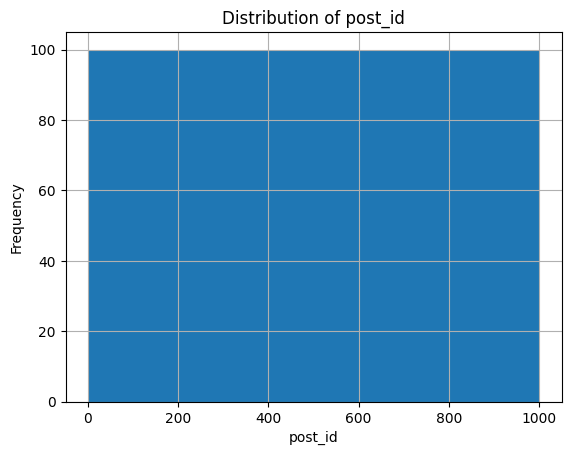

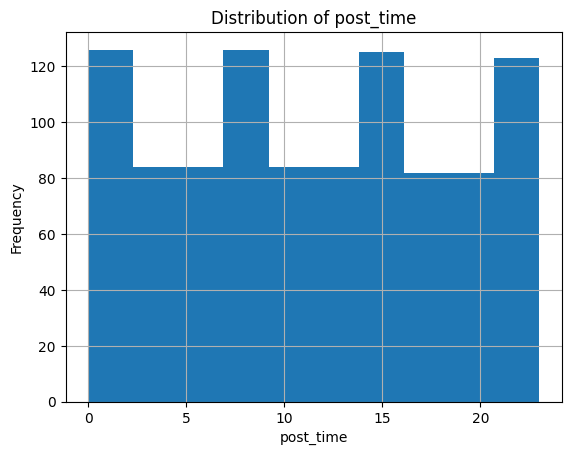

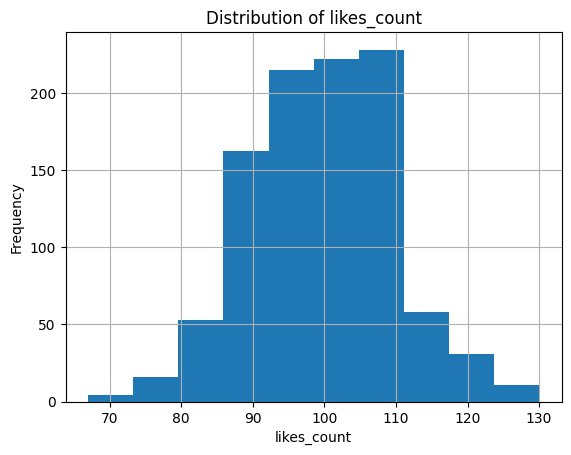

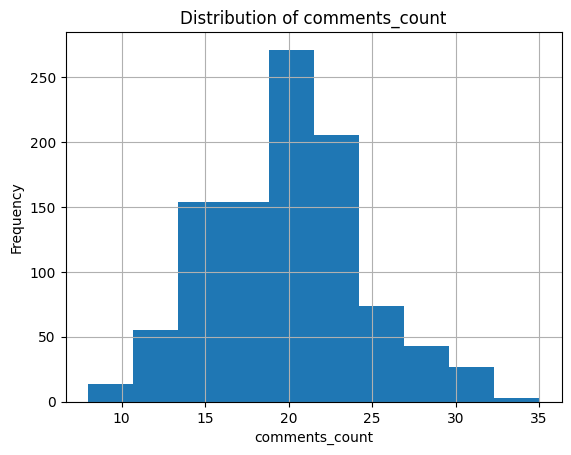

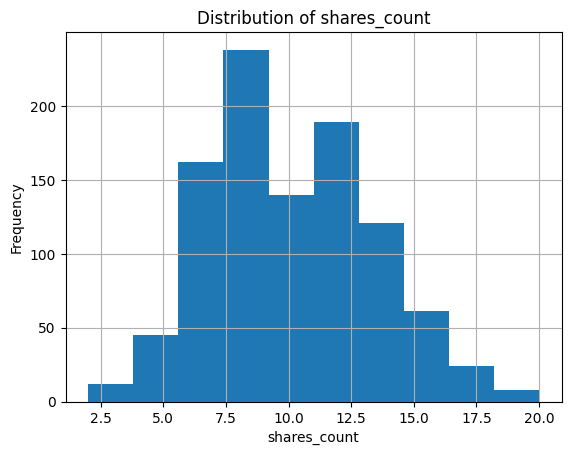

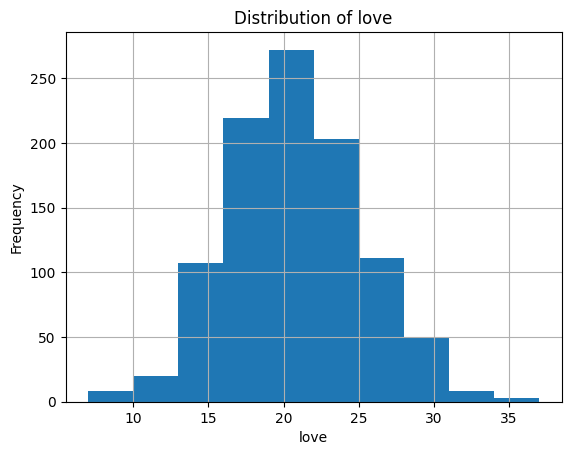

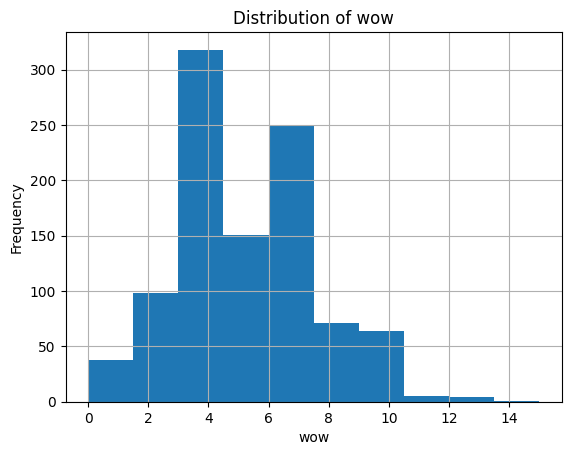

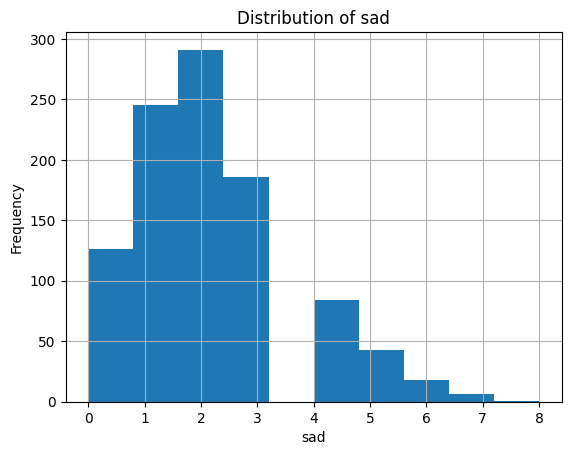

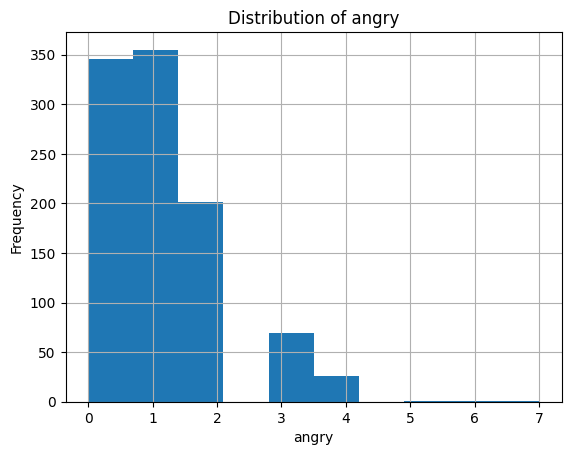

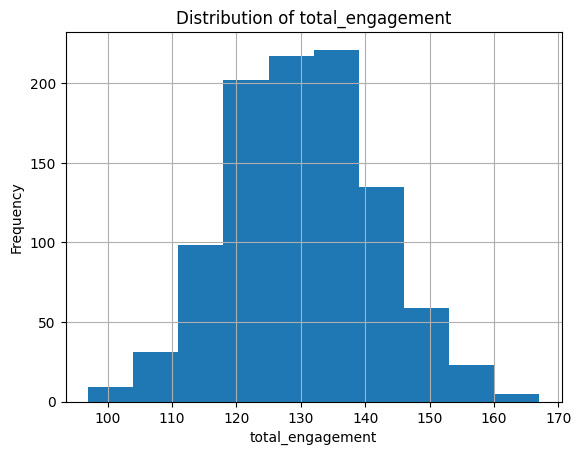

In [10]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**Engagement Analysis**

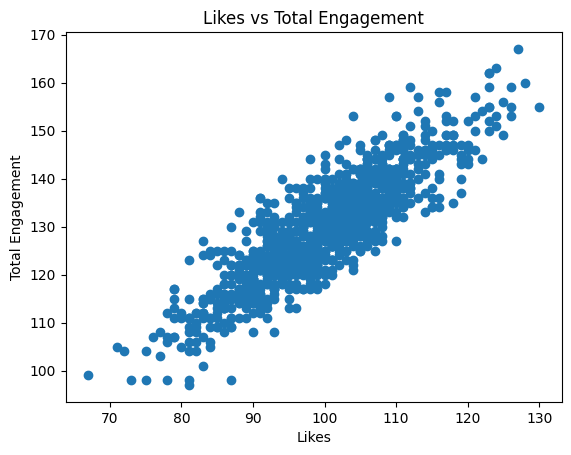

In [11]:
plt.figure()
plt.scatter(df['likes_count'], df['total_engagement'])
plt.title("Likes vs Total Engagement")
plt.xlabel("Likes")
plt.ylabel("Total Engagement")
plt.show()


**Correlation Heatmap**

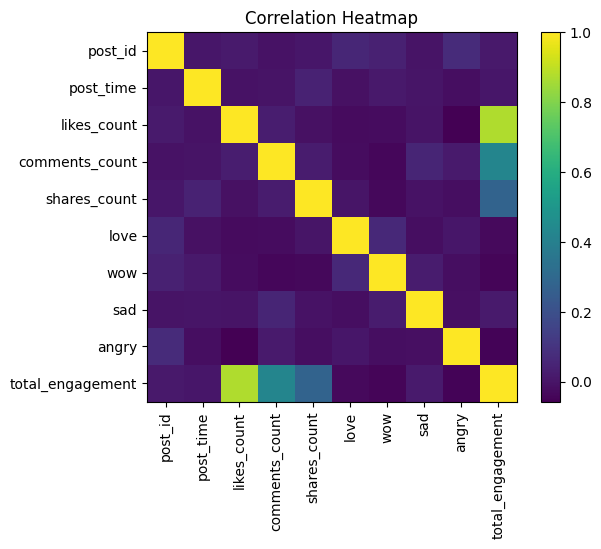

In [12]:
corr = df[numeric_cols].corr()

plt.figure()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.show()

 **Time-based Analysis**

In [13]:
print("\nPosts by Day:\n", df['day_of_week'].value_counts())
print("\nPosts by Time of Day:\n", df['time_of_day'].value_counts())


Posts by Day:
 day_of_week
Wednesday    144
Thursday     144
Friday       144
Saturday     144
Sunday       144
Monday       144
Tuesday      136
Name: count, dtype: int64

Posts by Time of Day:
 time_of_day
night        333
morning      294
afternoon    209
evening      164
Name: count, dtype: int64


**Top Performing Posts**

In [14]:
top_posts = df.sort_values(by='total_engagement', ascending=False).head(10)
print("\nTop 10 Posts:\n", top_posts)


Top 10 Posts:
      post_id post_type food_category brand_name  post_date  post_time  \
525      526     image         sushi   chipotle 2025-01-22         21   
489      490     image         pizza     subway 2025-01-21          9   
574      575     image         salad    dominos 2025-01-24         22   
723      724     image        burger     subway 2025-01-31          3   
84        85     image        burger    dominos 2025-01-04         12   
401      402     video         sushi   chipotle 2025-01-17         17   
485      486     video         sushi     subway 2025-01-21          5   
318      319     image        burger     subway 2025-01-14          6   
959      960     image         sushi    dominos 2025-02-09         23   
916      917     video         salad     subway 2025-02-08          4   

     likes_count  comments_count  shares_count  love  wow  sad  angry  \
525          127              27            13    22    7    2      1   
489          124              24  

**Group Analysis**

In [15]:
engagement_by_type = df.groupby('post_type')['total_engagement'].mean()
print("\nAverage Engagement by Post Type:\n", engagement_by_type)

engagement_by_time = df.groupby('time_of_day')['total_engagement'].mean()
print("\nAverage Engagement by Time of Day:\n", engagement_by_time)


Average Engagement by Post Type:
 post_type
image    129.700000
video    129.890196
Name: total_engagement, dtype: float64

Average Engagement by Time of Day:
 time_of_day
afternoon    129.000000
evening      130.146341
morning      129.914966
night        130.021021
Name: total_engagement, dtype: float64
